<a href="https://colab.research.google.com/github/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab14/Lab_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Lab14/Data/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     4258.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          3.80e-192
Time:                         20:10:16   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

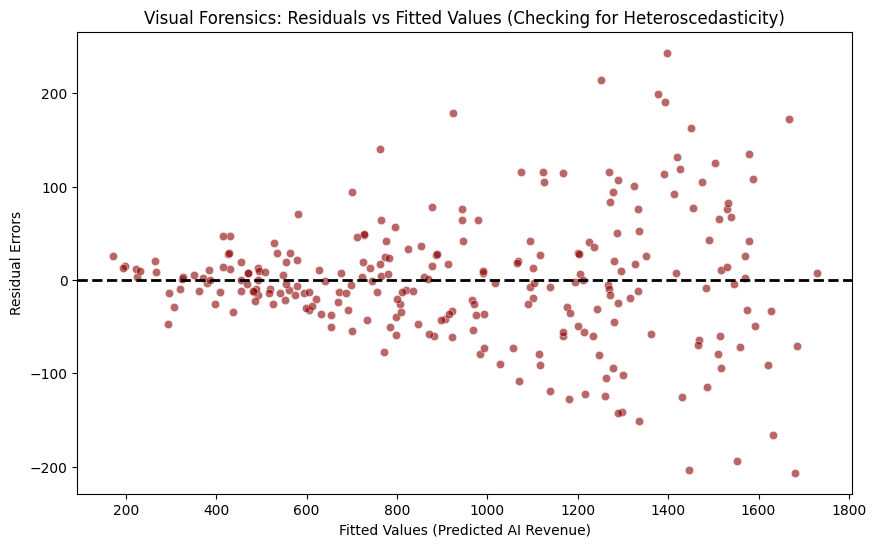

In [24]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [25]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- WHITE TEST RESULTS ---
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}


We can reject null hypothesis, since p-value is 0.00

In [26]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- VARIANCE INFLATION FACTORS ---
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}
{'LM Statistic': '51.64', 'LM-Test p-value': '0.00', 'F-Statistic': '12.70', 'F-Test p-value': '0.00'}


In [29]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')

# Print the summary of the robust model
print(robust_model.summary())

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())

                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     3555.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          9.05e-183
Time:                         20:12:31   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

Claude Code

In [7]:
!pip install streamlit plotly statsmodels pyngrok -q

In [8]:
%%writefile ols_diagnostic_dashboard.py
# paste your entire dashboard code here, starting from the docstring

Writing ols_diagnostic_dashboard.py


In [19]:
"""
OLS Regression Diagnostic Dashboard
=====================================
Interactive Streamlit app for diagnosing heteroscedasticity and
multicollinearity in OLS regression models using the Lalonde (1986)
NSW dataset — or any user-uploaded CSV.

Run locally:
    pip install streamlit plotly statsmodels pandas numpy scipy
    streamlit run ols_diagnostic_dashboard.py
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import io

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# st.set_page_config() must be the FIRST Streamlit call in the script.
# It configures the browser tab title, icon, and default layout width.
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    page_icon="📊",
    layout="wide",                  # "wide" uses the full browser viewport
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CSS — injected via st.markdown with unsafe_allow_html=True.
# Streamlit renders raw HTML/CSS when this flag is set, letting us override
# the default theme for a polished, data-science-lab aesthetic.
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap');

/* Root palette */
:root {
    --bg:        #0e1117;
    --surface:   #161b27;
    --border:    #252d3d;
    --accent:    #4f8ef7;
    --accent2:   #f7914f;
    --text:      #dde3f0;
    --muted:     #7a8499;
    --good:      #4fc97a;
    --warn:      #f7c94f;
    --bad:       #f74f4f;
}

html, body, [data-testid="stAppViewContainer"] {
    background-color: var(--bg);
    color: var(--text);
    font-family: 'IBM Plex Sans', sans-serif;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background-color: var(--surface);
    border-right: 1px solid var(--border);
}

/* Metric cards */
[data-testid="metric-container"] {
    background-color: var(--surface);
    border: 1px solid var(--border);
    border-radius: 8px;
    padding: 12px 16px;
}

/* Code / pre blocks */
pre, code {
    font-family: 'IBM Plex Mono', monospace !important;
    font-size: 0.78rem;
}

/* Section headers */
h1, h2, h3 {
    font-family: 'IBM Plex Mono', monospace;
    letter-spacing: -0.5px;
}

/* Divider line */
hr { border-color: var(--border); }

/* Tab highlight */
[data-baseweb="tab-highlight"] {
    background-color: var(--accent) !important;
}

/* Toggle / radio */
[data-testid="stRadio"] label { font-size: 0.85rem; }

/* Expander */
details summary {
    font-family: 'IBM Plex Mono', monospace;
    font-size: 0.82rem;
    color: var(--accent);
}
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────────────────
# @st.cache_data  ← Streamlit's data-layer cache.
# The decorated function runs ONCE and its return value is stored in memory
# (keyed by the function arguments). On every subsequent re-run — which
# happens whenever any widget changes — Streamlit returns the cached result
# instantly instead of re-executing the function body.
# Use for: data loading, I/O, pandas transformations.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_data
def load_lalonde() -> pd.DataFrame:
    """
    Load the Lalonde NSW dataset directly from a public URL.
    This is cached so it's fetched only once per session.
    """
    url = (
        "https://raw.githubusercontent.com/matheusfacure/"
        "python-causality-handbook/master/causal-inference-for-the-brave"
        "-and-true/data/trainees.csv"
    )
    try:
        df = pd.read_csv(url)
        return df
    except Exception:
        # Fallback: synthesise a small Lalonde-like dataset so the app
        # still runs offline / in restricted environments.
        rng = np.random.default_rng(42)
        n = 445
        df = pd.DataFrame({
            "treat":   rng.integers(0, 2, n),
            "age":     rng.integers(17, 55, n),
            "educ":    rng.integers(3, 16, n),
            "black":   rng.integers(0, 2, n),
            "hisp":    rng.integers(0, 2, n),
            "married": rng.integers(0, 2, n),
            "nodegree":rng.integers(0, 2, n),
            "re74":    np.maximum(0, rng.normal(3000, 5000, n)),
            "re75":    np.maximum(0, rng.normal(3000, 5000, n)),
            "re78":    np.maximum(0, rng.normal(5000, 7000, n)),
        })
        return df


@st.cache_data
def load_user_csv(file_bytes: bytes) -> pd.DataFrame:
    """Parse an uploaded CSV file. Cached by file content hash."""
    return pd.read_csv(io.BytesIO(file_bytes))


# ─────────────────────────────────────────────────────────────────────────────
# @st.cache_resource  ← Model/object cache (heavier, singleton).
# Unlike cache_data (which deep-copies), cache_resource stores a single
# shared object — ideal for fitted models, database connections, or anything
# expensive to construct and safe to share across sessions.
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_resource
def fit_models(df_hash: str, outcome: str, features: tuple):
    """
    Fit Naive OLS and HC3-robust OLS for the given specification.
    `df_hash` is a string fingerprint of the dataframe so the cache
    invalidates whenever the data changes.
    `features` must be a tuple (not list) because cache keys must be hashable.
    """
    # This global reference is set before calling this function (see below).
    df = _CACHED_DF

    X_raw = df[list(features)].copy()
    y     = df[outcome].copy()

    # Drop rows with any NaN in selected columns
    mask = X_raw.notna().all(axis=1) & y.notna()
    X_raw, y = X_raw[mask], y[mask]

    # Add constant for intercept — statsmodels does NOT add one automatically
    X = sm.add_constant(X_raw)

    # ── Naive OLS (homoscedastic standard errors) ──────────────────────────
    naive_model  = sm.OLS(y, X).fit()

    # ── HC3-robust OLS (heteroscedasticity-consistent covariance) ──────────
    # cov_type="HC3" uses the MacKinnon–White (1985) small-sample correction.
    # HC3 down-weights high-leverage observations, making it the safest
    # default for cross-sectional data.
    robust_model = sm.OLS(y, X).fit(cov_type="HC3")

    return naive_model, robust_model, X_raw, y, X


def compute_vif(X_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor for each predictor.
    VIF_j = 1 / (1 - R²_j) where R²_j is from regressing X_j on all others.

    Rule of thumb:
        VIF < 5   → no concern
        5 ≤ VIF < 10 → moderate multicollinearity
        VIF ≥ 10  → severe multicollinearity
    """
    # Drop constant column if present (VIF is undefined for it)
    cols = [c for c in X_raw.columns if c != "const"]
    X_arr = X_raw[cols].dropna().values.astype(float)

    vif_vals = [
        variance_inflation_factor(X_arr, i) for i in range(X_arr.shape[1])
    ]
    return pd.DataFrame({"Feature": cols, "VIF": vif_vals}).sort_values(
        "VIF", ascending=False
    )


def run_diagnostics(model, y: pd.Series) -> dict:
    """
    Run Breusch-Pagan, White's test, and Durbin-Watson on a fitted model.
    Returns a dict of test stats and p-values.
    """
    resid = model.resid

    # Breusch-Pagan test for heteroscedasticity
    bp_lm, bp_p, _, _ = het_breuschpagan(resid, model.model.exog)

    # White's test (more general — allows nonlinear heteroscedasticity)
    try:
        wh_lm, wh_p, _, _ = het_white(resid, model.model.exog)
    except Exception:
        wh_lm, wh_p = np.nan, np.nan

    # Durbin-Watson: tests for first-order autocorrelation in residuals
    # DW ≈ 2 → no autocorrelation; DW < 1.5 or > 2.5 → concern
    dw = durbin_watson(resid)

    return {
        "BP LM Stat":  round(bp_lm, 4),
        "BP p-value":  round(bp_p,  4),
        "White LM Stat": round(wh_lm, 4) if not np.isnan(wh_lm) else "N/A",
        "White p-value": round(wh_p,  4) if not np.isnan(wh_p)  else "N/A",
        "Durbin-Watson": round(dw, 4),
    }


# ─────────────────────────────────────────────────────────────────────────────
# PLOTLY HELPERS — all charts use a shared dark template to stay consistent
# with the CSS theme.
# ─────────────────────────────────────────────────────────────────────────────
PLOTLY_THEME = dict(
    template="plotly_dark",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(family="IBM Plex Mono, monospace", size=11, color="#dde3f0"),
    margin=dict(l=40, r=20, t=40, b=40),
)


def plot_residuals_vs_fitted(model, title: str) -> go.Figure:
    fitted = model.fittedvalues
    resid  = model.resid

    fig = px.scatter(
        x=fitted, y=resid,
        labels={"x": "Fitted Values", "y": "Residuals"},
        title=title,
        opacity=0.65,
        color_discrete_sequence=["#4f8ef7"],
    )
    # Horizontal zero line — residuals should scatter randomly around 0
    fig.add_hline(y=0, line_dash="dash", line_color="#f7914f", line_width=1.5)
    # Lowess smoother to reveal any systematic pattern
    lowess = sm.nonparametric.lowess(resid, fitted, frac=0.4)
    fig.add_trace(go.Scatter(
        x=lowess[:, 0], y=lowess[:, 1],
        mode="lines", name="LOWESS",
        line=dict(color="#f7c94f", width=2),
    ))
    fig.update_layout(**PLOTLY_THEME)
    return fig


def plot_scale_location(model) -> go.Figure:
    fitted = model.fittedvalues
    sqrt_abs_resid = np.sqrt(np.abs(model.resid))

    fig = px.scatter(
        x=fitted, y=sqrt_abs_resid,
        labels={"x": "Fitted Values", "y": "√|Standardised Residuals|"},
        title="Scale-Location (Spread-Level)",
        opacity=0.65,
        color_discrete_sequence=["#4fc97a"],
    )
    lowess = sm.nonparametric.lowess(sqrt_abs_resid, fitted, frac=0.4)
    fig.add_trace(go.Scatter(
        x=lowess[:, 0], y=lowess[:, 1],
        mode="lines", name="LOWESS",
        line=dict(color="#f7c94f", width=2),
    ))
    fig.update_layout(**PLOTLY_THEME)
    return fig


def plot_qq(model) -> go.Figure:
    """Q-Q plot for normality of residuals."""
    resid_std = (model.resid - model.resid.mean()) / model.resid.std()
    (osm, osr), _ = stats.probplot(resid_std, dist="norm")

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=osm, y=osr, mode="markers",
        marker=dict(color="#4f8ef7", size=5, opacity=0.7),
        name="Residuals",
    ))
    # 45° reference line
    lo, hi = min(osm), max(osm)
    fig.add_trace(go.Scatter(
        x=[lo, hi], y=[lo, hi], mode="lines",
        line=dict(color="#f74f4f", dash="dash", width=1.5),
        name="Normal Reference",
    ))
    fig.update_layout(
        title="Q-Q Plot of Residuals",
        xaxis_title="Theoretical Quantiles",
        yaxis_title="Sample Quantiles",
        **PLOTLY_THEME,
    )
    return fig


def plot_residual_histogram(model) -> go.Figure:
    fig = px.histogram(
        x=model.resid, nbins=40,
        labels={"x": "Residuals", "y": "Count"},
        title="Residual Distribution",
        color_discrete_sequence=["#4f8ef7"],
        opacity=0.8,
    )
    # Overlay a normal density curve
    mu, sigma = model.resid.mean(), model.resid.std()
    x_line = np.linspace(model.resid.min(), model.resid.max(), 200)
    y_line = stats.norm.pdf(x_line, mu, sigma)
    # Scale density to histogram counts
    bin_width = (model.resid.max() - model.resid.min()) / 40
    y_line_scaled = y_line * len(model.resid) * bin_width
    fig.add_trace(go.Scatter(
        x=x_line, y=y_line_scaled, mode="lines",
        line=dict(color="#f7914f", width=2), name="Normal Fit"
    ))
    fig.update_layout(**PLOTLY_THEME)
    return fig


def plot_vif_bar(vif_df: pd.DataFrame) -> go.Figure:
    """
    Horizontal bar chart of VIF scores.
    Bars are coloured by severity: green < 5, amber 5–10, red ≥ 10.
    """
    colors = [
        "#4fc97a" if v < 5 else ("#f7c94f" if v < 10 else "#f74f4f")
        for v in vif_df["VIF"]
    ]
    fig = go.Figure(go.Bar(
        x=vif_df["VIF"],
        y=vif_df["Feature"],
        orientation="h",
        marker_color=colors,
        text=[f"{v:.2f}" for v in vif_df["VIF"]],
        textposition="outside",
    ))
    # Threshold lines
    fig.add_vline(x=5,  line_dash="dot", line_color="#f7c94f",
                  annotation_text="VIF=5",  annotation_position="top right")
    fig.add_vline(x=10, line_dash="dot", line_color="#f74f4f",
                  annotation_text="VIF=10", annotation_position="top right")
    fig.update_layout(
        title="Variance Inflation Factors",
        xaxis_title="VIF Score",
        yaxis_title="",
        **PLOTLY_THEME,
    )
    return fig


def plot_coef_comparison(naive_model, robust_model) -> go.Figure:
    """
    Side-by-side coefficient CIs: Naive OLS vs HC3-robust.
    Helps visualise how SE inflation under heteroscedasticity widens CIs.
    """
    params = naive_model.params.index.tolist()

    fig = go.Figure()
    for m, name, color in [
        (naive_model,  "Naive OLS", "#4f8ef7"),
        (robust_model, "HC3 Robust", "#f7914f"),
    ]:
        ci_lo = m.conf_int()[0]
        ci_hi = m.conf_int()[1]
        fig.add_trace(go.Scatter(
            x=m.params.values,
            y=params,
            mode="markers",
            marker=dict(color=color, size=9, symbol="circle"),
            name=name,
            error_x=dict(
                type="data",
                symmetric=False,
                array=ci_hi.values - m.params.values,
                arrayminus=m.params.values - ci_lo.values,
                color=color,
                thickness=1.5,
                width=4,
            ),
        ))
    fig.add_vline(x=0, line_dash="dash", line_color="#7a8499", line_width=1)
    fig.update_layout(
        title="Coefficient Estimates with 95% CIs: Naive vs HC3",
        xaxis_title="Coefficient Value",
        yaxis_title="",
        **PLOTLY_THEME,
    )
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR — st.sidebar.* widgets render in the collapsible left panel.
# Widgets here control global app state and persist across tab switches
# because Streamlit re-runs the entire script top-to-bottom on every
# interaction, preserving widget values via st.session_state.
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## ⚙️ Configuration")
    st.markdown("---")

    # ── Data source ──────────────────────────────────────────────────────────
    st.markdown("### 📂 Data Source")
    data_source = st.radio(
        "Choose dataset",
        ["Lalonde NSW (default)", "Upload CSV"],
        # key= gives this widget a stable name in st.session_state
        key="data_source",
        help="Use the canonical Lalonde dataset or bring your own CSV.",
    )

    _CACHED_DF = None   # global placeholder; filled below

    if data_source == "Upload CSV":
        uploaded = st.file_uploader("Upload a CSV file", type=["csv"])
        if uploaded:
            _CACHED_DF = load_user_csv(uploaded.read())
            st.success(f"Loaded: {uploaded.name} ({len(_CACHED_DF):,} rows)")
        else:
            st.info("Awaiting upload…")
    else:
        _CACHED_DF = load_lalonde()
        st.success(f"Lalonde NSW loaded ({len(_CACHED_DF):,} rows)")

    if _CACHED_DF is None:
        st.stop()   # st.stop() halts execution of the remainder of the script

    st.markdown("---")

    # ── Variable selection ───────────────────────────────────────────────────
    st.markdown("### 🎯 Model Specification")

    num_cols = _CACHED_DF.select_dtypes(include=np.number).columns.tolist()

    outcome = st.selectbox(
        "Outcome variable (Y)",
        num_cols,
        index=num_cols.index("re78") if "re78" in num_cols else 0,
        key="outcome",
    )

    default_features = [c for c in ["treat","age","educ","black","hisp",
                                     "married","nodegree","re74","re75"]
                        if c in num_cols and c != outcome]

    features = st.multiselect(
        "Predictor variables (X)",
        [c for c in num_cols if c != outcome],
        default=default_features or [c for c in num_cols if c != outcome][:4],
        key="features",
    )

    if len(features) < 1:
        st.warning("Select at least one predictor.")
        st.stop()

    st.markdown("---")

    # ── Model toggle ─────────────────────────────────────────────────────────
    # This radio controls which OLS summary is shown in the Summary tab.
    st.markdown("### 🔀 Model Summary Toggle")
    model_choice = st.radio(
        "Display summary for:",
        ["Naive OLS", "HC3 Robust OLS"],
        key="model_choice",
    )

    st.markdown("---")
    st.markdown(
        "<small style='color:#7a8499'>ECON 3916 · Financial Econometrics<br>"
        "Lalonde (1986) NSW Dataset</small>",
        unsafe_allow_html=True,
    )


# ─────────────────────────────────────────────────────────────────────────────
# FIT MODELS — pass a hash so cache_resource invalidates on data/spec change.
# ─────────────────────────────────────────────────────────────────────────────
df_hash = str(pd.util.hash_pandas_object(_CACHED_DF).sum())
spec_hash = f"{df_hash}_{outcome}_{'_'.join(sorted(features))}"

naive_model, robust_model, X_raw, y, X = fit_models(
    spec_hash, outcome, tuple(features)
)

active_model = naive_model if model_choice == "Naive OLS" else robust_model

vif_df       = compute_vif(X_raw)
diagnostics  = run_diagnostics(naive_model, y)  # always run on naive residuals


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PANEL — st.tabs() creates a tab bar; each `with tab_X:` block scopes
# its widgets so only the active tab's content is rendered in the viewport.
# All tabs are still executed on every re-run (Streamlit is not lazy by tab),
# but widgets in inactive tabs are simply hidden by CSS.
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("# 📊 OLS Diagnostic Dashboard")
st.markdown(
    f"**Outcome:** `{outcome}` &nbsp;|&nbsp; "
    f"**Predictors:** `{', '.join(features)}` &nbsp;|&nbsp; "
    f"**N =** {len(y):,}",
    unsafe_allow_html=True,
)
st.markdown("---")

tab_overview, tab_residuals, tab_tests, tab_vif, tab_coef = st.tabs([
    "🏠 Overview",
    "🔍 Residual Plots",
    "🧪 Diagnostic Tests",
    "📐 VIF / Multicollinearity",
    "📈 Coefficient Comparison",
])


# ── TAB 1: OVERVIEW ──────────────────────────────────────────────────────────
with tab_overview:
    # st.columns([w1, w2]) creates a two-column layout with relative widths.
    # Content inside each `with col_X:` block flows into that column.
    col_left, col_right = st.columns([1, 1])

    with col_left:
        st.markdown("### Model Summary")
        st.markdown(
            f"Showing: **{model_choice}**  \n"
            f"<small style='color:#7a8499'>Toggle in the sidebar →</small>",
            unsafe_allow_html=True,
        )
        # st.text() renders monospaced preformatted text — perfect for
        # statsmodels .summary() output which uses fixed-width formatting.
        st.text(active_model.summary().as_text())

    with col_right:
        st.markdown("### Key Fit Statistics")

        # st.metric() renders a labelled KPI card with an optional delta arrow.
        m1, m2 = st.columns(2)
        with m1:
            st.metric("R²",        f"{naive_model.rsquared:.4f}")
            st.metric("Adj. R²",   f"{naive_model.rsquared_adj:.4f}")
            st.metric("F-Statistic", f"{naive_model.fvalue:.2f}")
        with m2:
            st.metric("AIC",  f"{naive_model.aic:.1f}")
            st.metric("BIC",  f"{naive_model.bic:.1f}")
            st.metric("Obs.", f"{int(naive_model.nobs):,}")

        st.markdown("---")
        st.markdown("### Quick Diagnostics Snapshot")

        # Colour-coded BP test result
        bp_p = diagnostics["BP p-value"]
        bp_flag = "🔴 Heteroscedasticity detected" if bp_p < 0.05 else "🟢 No evidence of heteroscedasticity"
        st.markdown(f"**Breusch-Pagan test:** {bp_flag} (p = {bp_p})")

        dw = diagnostics["Durbin-Watson"]
        dw_flag = "🟢 No autocorrelation" if 1.5 < dw < 2.5 else "🟡 Possible autocorrelation"
        st.markdown(f"**Durbin-Watson:** {dw_flag} (DW = {dw})")

        max_vif = vif_df["VIF"].max()
        vif_flag = (
            "🔴 Severe multicollinearity" if max_vif >= 10
            else ("🟡 Moderate multicollinearity" if max_vif >= 5
                  else "🟢 No multicollinearity concern")
        )
        st.markdown(f"**Max VIF:** {vif_flag} (max = {max_vif:.2f})")

        # st.expander() creates a collapsible section — keeps the UI clean
        with st.expander("📖 How to interpret these flags"):
            st.markdown("""
**Breusch-Pagan (BP) test**
- H₀: residual variance is constant (homoscedasticity)
- p < 0.05 → reject H₀ → heteroscedasticity present
- Remedy: switch to HC3-robust standard errors (see sidebar toggle)

**Durbin-Watson**
- Range [0, 4]; DW ≈ 2 means no serial correlation
- DW < 1.5 → positive autocorrelation; DW > 2.5 → negative autocorrelation
- Mainly relevant for time-series data

**VIF (Variance Inflation Factor)**
- Measures how much a regressor's variance is inflated by collinearity
- VIF < 5: safe | 5–10: monitor | ≥ 10: problematic
- Remedy: drop collinear features, PCA, or ridge regularisation
            """)


# ── TAB 2: RESIDUAL PLOTS ────────────────────────────────────────────────────
with tab_residuals:
    st.markdown("### Residual Diagnostic Plots")
    st.markdown(
        "<small style='color:#7a8499'>All plots use the <b>Naive OLS</b> "
        "residuals — this is standard practice for visual diagnostics.</small>",
        unsafe_allow_html=True,
    )

    # 2×2 grid of plots using st.columns
    r1c1, r1c2 = st.columns(2)
    r2c1, r2c2 = st.columns(2)

    with r1c1:
        # Residuals vs Fitted — the primary heteroscedasticity diagnostic.
        # A fan shape (widening spread) indicates non-constant variance.
        st.plotly_chart(
            plot_residuals_vs_fitted(naive_model, "Residuals vs Fitted"),
            use_container_width=True,  # stretches to column width
        )
    with r1c2:
        # Scale-Location — reinforces Residuals vs Fitted.
        # A flat LOWESS line indicates homoscedasticity.
        st.plotly_chart(
            plot_scale_location(naive_model),
            use_container_width=True,
        )
    with r2c1:
        # Q-Q plot — tests normality of residuals.
        # Points deviating from the 45° line → non-normal tails.
        st.plotly_chart(
            plot_qq(naive_model),
            use_container_width=True,
        )
    with r2c2:
        # Residual histogram — complements Q-Q; reveals skew / heavy tails.
        st.plotly_chart(
            plot_residual_histogram(naive_model),
            use_container_width=True,
        )

    st.markdown("---")
    st.markdown("### Residuals vs Individual Predictors")
    st.markdown(
        "<small style='color:#7a8499'>Select a predictor to inspect "
        "partial residual patterns.</small>",
        unsafe_allow_html=True,
    )

    # Selectbox widget — re-runs the script and re-draws only this chart
    selected_pred = st.selectbox("Predictor", features, key="pred_select")

    fig_partial = px.scatter(
        x=X_raw[selected_pred],
        y=naive_model.resid,
        labels={"x": selected_pred, "y": "Residuals"},
        title=f"Residuals vs {selected_pred}",
        opacity=0.65,
        color_discrete_sequence=["#4f8ef7"],
        trendline="lowess",
        trendline_color_override="#f7c94f",
    )
    fig_partial.add_hline(y=0, line_dash="dash",
                          line_color="#f7914f", line_width=1.5)
    fig_partial.update_layout(**PLOTLY_THEME)
    st.plotly_chart(fig_partial, use_container_width=True)


# ── TAB 3: DIAGNOSTIC TESTS ──────────────────────────────────────────────────
with tab_tests:
    st.markdown("### Formal Diagnostic Test Results")

    # st.columns with equal widths for test stat cards
    c1, c2, c3, c4, c5 = st.columns(5)
    metrics_map = {
        c1: ("BP LM Stat",   "Breusch-Pagan LM"),
        c2: ("BP p-value",   "BP p-value"),
        c3: ("White LM Stat","White's LM Stat"),
        c4: ("White p-value","White's p-value"),
        c5: ("Durbin-Watson","Durbin-Watson"),
    }
    for col, (key, label) in metrics_map.items():
        val = diagnostics[key]
        with col:
            # Delta colours: p-values above 0.05 are "good" (green delta)
            if "p-value" in key and isinstance(val, float):
                delta = "✓ pass" if val > 0.05 else "✗ fail"
                delta_color = "normal" if val > 0.05 else "inverse"
                st.metric(label, val, delta=delta, delta_color=delta_color)
            else:
                st.metric(label, val)

    st.markdown("---")

    # Side-by-side coefficient tables
    st.markdown("### Coefficient Table: Naive vs HC3-Robust")
    t_left, t_right = st.columns(2)

    def make_coef_table(model, name: str) -> pd.DataFrame:
        return pd.DataFrame({
            "Coef.":  model.params.round(4),
            "Std Err": model.bse.round(4),
            "t-stat":  model.tvalues.round(4),
            "p-value": model.pvalues.round(4),
            "[0.025":  model.conf_int()[0].round(4),
            "0.975]":  model.conf_int()[1].round(4),
        }).rename_axis("Variable")

    with t_left:
        st.markdown("**Naive OLS**")
        # st.dataframe() renders an interactive, sortable table.
        # highlight_max / highlight_min apply pandas Styler colourings.
        naive_tbl = make_coef_table(naive_model, "Naive OLS")
        st.dataframe(
            naive_tbl.style.background_gradient(
                subset=["p-value"], cmap="RdYlGn_r", vmin=0, vmax=0.1
            ),
            use_container_width=True,
        )

    with t_right:
        st.markdown("**HC3-Robust OLS**")
        robust_tbl = make_coef_table(robust_model, "HC3 Robust")
        st.dataframe(
            robust_tbl.style.background_gradient(
                subset=["p-value"], cmap="RdYlGn_r", vmin=0, vmax=0.1
            ),
            use_container_width=True,
        )

    with st.expander("📐 How SE changes under HC3 correction"):
        st.markdown("""
Under **OLS**, standard errors assume Var(ε) = σ²I (homoscedasticity).
If this fails, SEs are biased — typically **understated**, inflating t-statistics
and causing false positives.

**HC3** (MacKinnon & White, 1985) estimates a heteroscedasticity-consistent
covariance matrix:

> V̂_HC3 = (X'X)⁻¹ · [Σ ê²ᵢ / (1 − hᵢᵢ)²] · (X'X)⁻¹

where hᵢᵢ is the leverage of observation i. The (1 − hᵢᵢ)² denominator
**penalises high-leverage points**, making HC3 conservative and safe for
small samples.

**What to look for in the tables:**
- If HC3 SEs are *larger* than naive SEs → naive SEs were underestimated
- If a coefficient flips significance under HC3 → the naive result was spurious
- p-values highlighted red = significant at α = 0.10
        """)


# ── TAB 4: VIF / MULTICOLLINEARITY ──────────────────────────────────────────
with tab_vif:
    st.markdown("### Variance Inflation Factor Analysis")

    vif_col, explain_col = st.columns([1.5, 1])

    with vif_col:
        # Interactive Plotly bar chart
        st.plotly_chart(plot_vif_bar(vif_df), use_container_width=True)

    with explain_col:
        st.markdown("#### VIF Scores")
        # Colour the VIF column using a custom styler
        def colour_vif(val):
            if val >= 10: return "color: #f74f4f; font-weight: 600"
            if val >= 5:  return "color: #f7c94f"
            return "color: #4fc97a"

        st.dataframe(
            vif_df.style.applymap(colour_vif, subset=["VIF"]).format({"VIF": "{:.3f}"}),
            use_container_width=True,
            height=300,
        )

        st.markdown("---")
        st.markdown("#### Severity Legend")
        st.markdown("""
| Colour | VIF Range | Interpretation |
|--------|-----------|----------------|
| 🟢 Green | < 5 | No concern |
| 🟡 Amber | 5 – 10 | Monitor |
| 🔴 Red | ≥ 10 | Severe collinearity |
        """)

    # Correlation heatmap of predictors
    st.markdown("---")
    st.markdown("### Predictor Correlation Matrix")

    corr = X_raw.corr()
    fig_corr = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1, zmax=1,
        text_auto=".2f",
        title="Pearson Correlation Heatmap",
        aspect="auto",
    )
    fig_corr.update_layout(**PLOTLY_THEME)
    st.plotly_chart(fig_corr, use_container_width=True)

    with st.expander("📖 Interpreting VIF and Correlation"):
        st.markdown("""
**VIF vs Pairwise Correlation**

Pairwise correlation only flags *bivariate* collinearity.
VIF captures *multivariate* collinearity — e.g., X₁ = 0.5X₂ + 0.5X₃
would have low pairwise correlations but high VIF.

**Common culprits in the Lalonde data:**
- `re74` and `re75` (earnings in adjacent years) are typically correlated
- Demographic dummies (black, hisp, married) can be linearly dependent
  on each other if the dataset has limited demographic variation

**Remedies for high VIF:**
1. **Drop** one of the collinear predictors (check economic justification)
2. **PCA** — replace correlated predictors with orthogonal components
3. **Ridge regression** — L2 penalty shrinks collinear coefficients
4. **Mean-centre** continuous predictors (reduces collinearity with interaction terms)
        """)


# ── TAB 5: COEFFICIENT COMPARISON ────────────────────────────────────────────
with tab_coef:
    st.markdown("### Naive OLS vs HC3-Robust: Coefficient CI Comparison")
    st.markdown(
        "<small style='color:#7a8499'>"
        "Overlapping intervals of different width reveal where heteroscedasticity "
        "inflates/deflates naive SEs. A robust CI wider than the naive CI signals "
        "the naive model was overconfident for that coefficient."
        "</small>",
        unsafe_allow_html=True,
    )

    st.plotly_chart(plot_coef_comparison(naive_model, robust_model),
                    use_container_width=True)

    st.markdown("---")
    st.markdown("### SE Ratio: HC3 / Naive")

    se_ratio = (robust_model.bse / naive_model.bse).reset_index()
    se_ratio.columns = ["Variable", "SE Ratio (HC3 / Naive)"]
    se_ratio["SE Ratio (HC3 / Naive)"] = se_ratio["SE Ratio (HC3 / Naive)"].round(4)

    fig_ratio = px.bar(
        se_ratio, x="Variable", y="SE Ratio (HC3 / Naive)",
        color="SE Ratio (HC3 / Naive)",
        color_continuous_scale="RdYlGn_r",
        title="SE Inflation / Deflation Factor (HC3 vs Naive)",
    )
    fig_ratio.add_hline(y=1, line_dash="dash",
                        line_color="#4f8ef7", line_width=1.5,
                        annotation_text="Ratio = 1 (no change)",
                        annotation_position="top right")
    fig_ratio.update_layout(**PLOTLY_THEME)
    st.plotly_chart(fig_ratio, use_container_width=True)

    with st.expander("📖 Reading the SE Ratio chart"):
        st.markdown("""
- **Ratio > 1**: HC3 SE is larger → naive OLS *underestimated* uncertainty
  for this variable. Under heteroscedasticity, t-stats were too large and
  significance was overstated.
- **Ratio < 1**: HC3 SE is smaller → rare, but possible when heteroscedasticity
  happens to inflate residuals for low-leverage observations.
- **Ratio ≈ 1**: HC3 correction makes little difference — this coefficient's
  inference is robust regardless of the SE estimator chosen.

The coefficient with the **largest ratio** is the one most affected by
heteroscedasticity and the one most in need of robust inference.
        """)


2026-03-23 20:01:14.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.685 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.688 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.696 No runtime found, using MemoryCacheStorageManager
2026-03-23 20:01:14.700 No runtime found, using MemoryCacheStorageManager
2026-03-23 20:01:14.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:01:14.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

ValueError: zero-size array to reduction operation maximum which has no identity